## ddHodge at toggle-switch

reproduce the results in Figure 4C,D of [Dynamo paper](https://doi.org/10.1016/j.cell.2021.12.045), and compare them to ddHodge.

## Setup

### Packages and functions

In [5]:
using GLMakie, LinearAlgebra 
using ForwardDiff: jacobian, derivative
using StatsBase: mean, median, msd, quantile

# Toggle switch system (same params. as Dynamo)
function toggleswitch(x;k=[0.5,0.5],a=[1,1],b=[1,1],n=4)
    [
         a[1]*x[1]^n/(k[1]^n+x[1]^n)+b[1]*k[1]^n/(k[1]^n+x[2]^n)-x[1],
         a[2]*x[2]^n/(k[2]^n+x[2]^n)+b[2]*k[2]^n/(k[2]^n+x[1]^n)-x[2]
    ]
 end

Jf(x) = jacobian(toggleswitch,x) # analytical Jacobian

Jf (generic function with 1 method)

### Makie theme

In [6]:
if false
    # for figure: white BG, vector graphics
    import CairoMakie
    CairoMakie.activate!(type="svg")
    linecolor = :black
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use: dark BG, raster graphics
    using GLMakie
    GLMakie.activate!(px_per_unit=1)
    linecolor = :black
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Load data

Generated results (saved as .h5ad) according to `fig1.ipynb` in [dynamo_submission](https://github.com/aristoteleo/dynamo_submission/tree/master)

In [7]:
import Muon
#h5file = "../data/dynamo_toggle.h5ad"
h5file = "../data/dynamo_toggle_2025revise_default.h5ad"
#h5file = "../data/dynamo_toggle_2025revise_scipy_M1000.h5ad"
adata = Muon.readh5ad(h5file,backed=false)
@show sum(adata.obs.control_point_pca)
fieldnames(typeof(adata))

sum(adata.obs.control_point_pca) = 251


(:file, :X, :obs, :obs_names, :var, :var_names, :obsm, :obsp, :varm, :varp, :layers, :uns)

In [8]:
X = adata.obsm["X_pca"]'
V = adata.obsm["velocity_pca"]'
pts = Point2f.(eachcol(X))
Jana = eachslice(adata.uns["jacobian_true"]["jacobian"],dims=3)
@assert all(norm.(Jf.(eachcol(X)) .- Jana) .< 1e-8) # analytical values should be same
Jdyn = eachslice(adata.uns["jacobian_pca"]["jacobian"],dims=3)
N = length(pts)

5000

## Run ddHodge

In [17]:
using Revise, ddHodge
@time g, kdtree = kNNGraph(X,6)
ddh = ddHodgeWorkflow(g,X,V,λ=0.1,ϵ=0.1,ssa=false,krytol=1e-32)

  0.013415 seconds (92.70 k allocations: 4.288 MiB)


[ Info: (1/4) Potential estimation
[ Info: ... done in 0.22 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 1.0
[ Info: ... done in 0.003 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 0.067 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 1.0
[ Info: ... done in 0.079 sec.


:::ddHodge::: values over graph {5000, 17732}, dimensions: 2 -> 2 (ssa: off)

## Compare the results to Dynamo
Note: $\mathrm{div}$, $\mathrm{curl}$ and $\det J_f$ are coordinate independent

In [10]:
divana = adata.obs.analytical_div
divdyn = adata.obs.divergence_pca
rotana = adata.obs.analytical_curl
rotdyn = adata.obs.curl_pca
hcat(
    [msd(pred, divana) for pred in [divdyn,ddh.div]], # div
    [msd(pred, rotana) for pred in [rotdyn,ddh.rot]], # rot
    [msd(pred, det.(Jana)) for pred in [det.(Jdyn),det.(ddh.J)]] # detJ
)

2×3 Matrix{Float64}:
 0.138939    0.100922    0.138419
 0.00289216  0.00312872  0.00514564

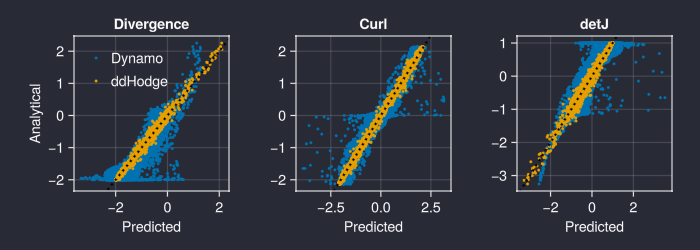

In [11]:
let ms = 4, lc = :black
    fig = Figure(size=(700,250))
    ax1 = Axis(fig[1,1],title="Divergence",xlabel="Predicted",ylabel="Analytical",aspect=1)
    ax2 = Axis(fig[1,2],title="Curl",xlabel="Predicted",aspect=1)
    ax3 = Axis(fig[1,3],title="detJ",xlabel="Predicted",aspect=1)
    pars = (;markersize=ms,rasterize=2) # shared params.
    scatter!(ax1,divdyn,divana,label="Dynamo";pars...)
    scatter!(ax1,ddh.div,divana,label="ddHodge";pars...)
    ablines!(ax1,0,1,color=lc,linestyle=:dot,linewidth=2)
    scatter!(ax2,rotdyn,rotana,;pars...)
    scatter!(ax2,ddh.rot,rotana;pars...)
    ablines!(ax2,0,1,color=lc,linestyle=:dot,linewidth=2)
    scatter!(ax3,det.(Jdyn),det.(Jana);pars...)
    scatter!(ax3,det.(ddh.J),det.(Jana);pars...)
    ablines!(ax3,0,1,color=lc,linestyle=:dot,linewidth=2)
    axislegend(ax1,position = :lt)
    linkyaxes!(ax1,ax2)
    fig
end

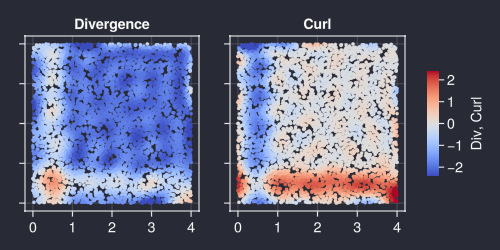

In [12]:
let ms = 5
    fig = Figure(size=(500,250))
    titles = ["Divergence", "Curl"]
    axs = [Axis(fig[1,i],title=titles[i],aspect=1) for i in 1:length(titles)]
    vmax = quantile(abs.(divdyn),0.99)
    plt = scatter!(axs[1], pts, color=divdyn, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax), rasterize=2)
    #scatter!(axs[1], pts[adata.obs.control_point_pca],markersize=1.5)
    scatter!(axs[2], pts, color=rotdyn, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax), rasterize=2)
    [axs[i].yticklabelsvisible = false for i in 1:2]
    linkaxes!(axs...)
    Colorbar(fig[1,3],plt,height=Relative(0.6),label="Div, Curl")
    fig
end

## ddHodge results

### Flow composition

[0.9878572704284542 0.012142729571545312]

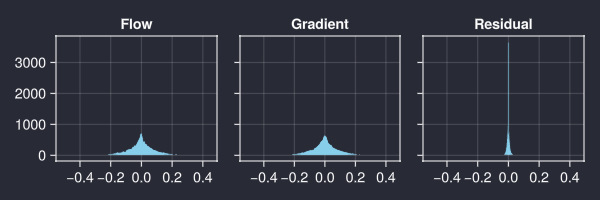

In [13]:
let
    fig = Figure(size=(600,200))
    titles = ["Flow", "Gradient", "Residual"]
    values = [ddh.w, -ddh.d0*ddh.u, ddh.w+ddh.d0*ddh.u]
    let n2s = norm.(values).^2; (n2s[2:3]/n2s[1])' end |> print
    axs = [Axis(fig[1,i],title=titles[i]) for i in 1:3]
    [hist!(axs[i], values[i], bins=200, color=:skyblue) for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in 2:3]
    linkaxes!(axs...)
    fig
end

### Potential, Divergence, Curl

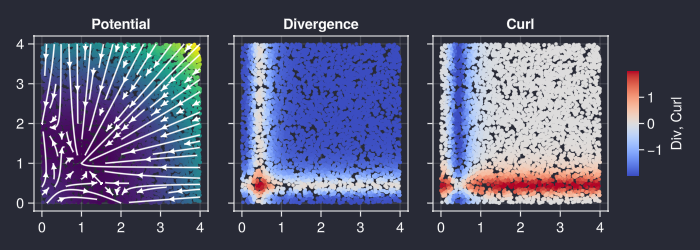

In [14]:
let ms = 5
    fig = Figure(size=(700,250))
    titles = ["Potential", "Divergence", "Curl"]
    axs = [Axis(fig[1,i],title=titles[i],aspect=1) for i in 1:3]
    scatter!(axs[1], pts, color=ddh.u, colormap=:viridis, markersize=ms, rasterize=2)
    streamplot!(
        axs[1], Point2f ∘ toggleswitch, 0..4, 0..4, gridsize=(20,20),
        linewidth=1.5, arrow_size=8.0, colormap=[:white] #Reverse(:Hiroshige)
    )
    vmax = quantile(abs.(ddh.div),0.99)
    plt = scatter!(axs[2], pts, color=ddh.div, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax), rasterize=2)
    scatter!(axs[3], pts, color=ddh.rot, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax), rasterize=2)
    [axs[i].yticklabelsvisible = false for i in 2:3]
    linkaxes!(axs...)
    Colorbar(fig[1,4],plt,height=Relative(0.6),label="Div, Curl")
    fig
end

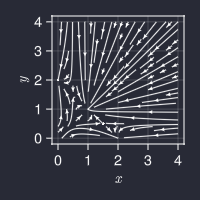

In [15]:
fig = Figure(size=(200,200))
ax = Axis(fig[1,1],xlabel=L"x",ylabel=L"y")
streamplot!(ax,
     Point2f ∘ toggleswitch, 0..4, 0..4, gridsize=(20,20), density=1.0,
     #linewidth=1.5, arrow_size=8.0, colormap=[:white], #Reverse(:Hiroshige)
     linewidth=1.0, arrow_size=5.0, colormap=[:white] #colormap=Reverse(:Hiroshige)
)
fig

### Elements of Jacobian matrix
... are the partial differentiations $\partial_x, \partial_y$ of the system (Hill eqs. in this case).

Note: The elements of $J_f$ depend on the selected coordinate.

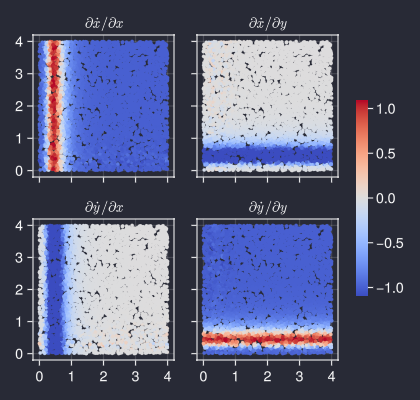

In [16]:
let ms = 5, analytical = false
    fdim = ddh.fdim
    varnames = ["x","y"]
    fmt(i,j) = L"\partial \dot{%$(varnames[i])}/\partial %$(varnames[j])"
    fig = Figure(size=(420,400))
    axs = [Axis(fig[i,j],aspect=1,title=fmt(i,j)) for i in 1:fdim, j in 1:fdim]
    vmax = quantile(vec(abs.(stack(ddh.J))),0.95)
    # Jacobian matrix in the canonical basis, i.e., xy coords.
    Js = analytical ? Jf.(pts) : [basischange(ddh.J[i],ddh.frames[i]) for i in 1:N]
    for i in 1:fdim, j in 1:fdim
        Jij = [J[i,j] for J in Js]
        scatter!(axs[i,j], pts, color=Jij, colormap=:coolwarm, markersize=ms, rasterize=2, colorrange=(-vmax,vmax))
    end
    [axs[i,j].yticklabelsvisible = false for i in 1:fdim for j in 2:fdim]
    [axs[i,j].xticklabelsvisible = false for i in 1:fdim-1 for j in 1:fdim]
    linkaxes!(axs...)
    Colorbar(fig[1:2,3],colormap=:coolwarm,colorrange=(-vmax,vmax),height=Relative(0.6))
    fig
end

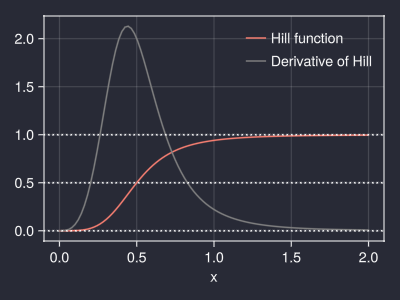

In [13]:
let k = 0.5, n=4
    xs = LinRange(0,2,100)
    f = x -> x^n/(k^n+x^n)
    f′ = x -> derivative(f,x)
    fig = Figure(size=(400,300))
    ax = Axis(fig[1,1],xlabel="x")
    lines!(xs,f.(xs),label="Hill function",color=:salmon)
    lines!(xs,f′.(xs),label="Derivative of Hill",color=:grey)
    hlines!([0,0.5,1],color=:white,linestyle=:dot)
    axislegend()
    fig
end

## Benchmarks: noise, size, time and errors

In [14]:
using DataFrames, Logging

### Noise levels

Notes:

* We consider the case of RNA-velocity data where the scaled degradation rate $\tilde \gamma = \gamma/\beta= 1.0$. Such condition emulates the situation where the steady state are on the diagonal $u_s = s_s$, i.e., the gene with the ratio of spliced to unspliced RNA count is 1:1.
* A proxy of the unspliced count $u$ of simulation data was generated by $u = \tilde \gamma s + v$ since $ds/dt \propto v = u - \tilde\gamma s$.
* To determine the signal-to-noise ratio, the scale of the signal was set to $\sigma = 1.0$ such that the sampled region $[0,4] \times [0,4]$ is almost covered by the 2D Gaussian distribution $\mathcal N((2,2), \sigma^2 I)$

In [15]:
import Random
using StatsBase: mad

Random.seed!(1234)
# γ: degradation; ratio of the unspliced/spliced data scale
tbnls = let σ=1.0, p = 0.01, k = 30, γ=1.0
    Q = [0.0 1.0; -1.0 0.0]
    noiselevels = [0.001, 0.01, 0.1]
    lambdas = [0.1, 1.0, 10.0]
    map(noiselevels) do p
        Xn = X + p*σ*randn(size(X)) # spliced + noise
        Un = γ*Xn + V + p*σ*randn(size(X)) # a proxy for unspliced w/ noise
        Vn = Un - γ*Xn # velocity from noisy data
        #@show sum(Vn)
        #J_a = jacobian.(toggleswitch,eachcol(X))
        #detJ_a = det.(J_a)
        #div_a = tr.(J_a)
        #rot_a = tr.(Q*J for J in J_a)
        Logging.disable_logging(Logging.Info)
        g, kdtree = kNNGraph(Xn,k)
        map(lambdas) do λ
        #λ = 0.1
        #map([6,12,30]) do k
            ddh = ddHodgeWorkflow(g,Xn,Vn,λ=λ,ssa=false,krytol=1e-32)
            Logging.disable_logging(Logging.Debug)
            (
                SNR = Int(1/p),
                lambda = λ,
                #k = k,
                ddh = ddh,
                mse_div = msd(ddh.div,divana),
                mse_curl = msd(ddh.rot,rotana),
                mse_detJ = msd(det.(ddh.J),det.(Jana)),
                mae_div = mad(ddh.div - divana),
                mae_curl = mad(ddh.rot - rotana),
                mae_detJ = mad(det.(ddh.J) - det.(Jana)),
            )
        end
    end
end |> stack |> vec |> DataFrame

[ Info: (1/4) Potential estimation
[ Info: ... done in 0.264 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 1.0
[ Info: ... done in 0.01 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 0.666 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 1.0
[ Info: ... done in 0.206 sec.
[ Info: (1/4) Potential estimation
[ Info: ... done in 0.263 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 1.0
[ Info: ... done in 0.011 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 0.182 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 1.0
[ Info: ... done in 0.24 sec.
[ Info: (1/4) Potential estimation
[ Info: ... done in 0.764 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 1.0
[ Info: ... done in 0.01 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 0.132 sec.
[ Info: (4/4) Jac

9×9 DataFrame
 Row │ SNR    lambda   ddh                                mse_div     mse_curl ⋯
     │ Int64  Float64  ddhResul…                          Float64     Float64  ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │  1000      0.1  ddhResult{Float64}(2, 2, false, …  0.00891023  0.008621 ⋯
   2 │  1000      1.0  ddhResult{Float64}(2, 2, false, …  0.0364287   0.036284
   3 │  1000     10.0  ddhResult{Float64}(2, 2, false, …  0.163124    0.161328
   4 │   100      0.1  ddhResult{Float64}(2, 2, false, …  0.024486    0.025621
   5 │   100      1.0  ddhResult{Float64}(2, 2, false, …  0.0407173   0.039393 ⋯
   6 │   100     10.0  ddhResult{Float64}(2, 2, false, …  0.163819    0.161661
   7 │    10      0.1  ddhResult{Float64}(2, 2, false, …  1.26116     2.75907
   8 │    10      1.0  ddhResult{Float64}(2, 2, false, …  0.376148    0.587441
   9 │    10     10.0  ddhResult{Float64}(2, 2, false, …  0.227315    0.225961 ⋯
                                                               5 columns omitted

In [17]:
tbnls[!,[:SNR, :lambda, :mse_div, :mae_div]] .|> x -> round.(x,digits=3)

Row,SNR,lambda,mse_div,mae_div
,Float64,Float64,Float64,Float64
1,1000.0,0.1,0.009,0.018
2,1000.0,1.0,0.036,0.026
3,1000.0,10.0,0.163,0.146
4,100.0,0.1,0.024,0.1
5,100.0,1.0,0.041,0.07
6,100.0,10.0,0.164,0.135
7,10.0,0.1,1.261,0.796
8,10.0,1.0,0.376,0.481
9,10.0,10.0,0.227,0.232


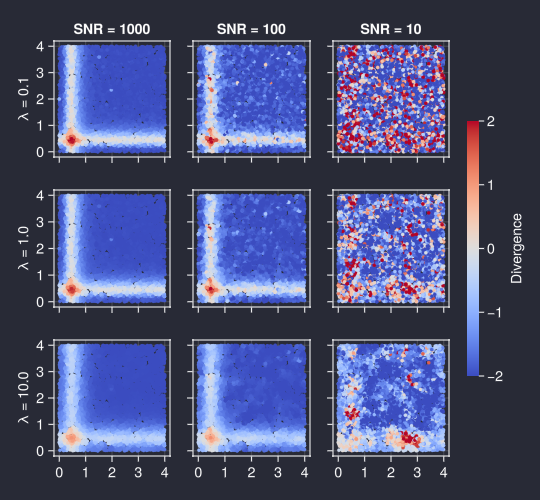

In [375]:
let cr = (-2,2)
    fig = Figure(size=(540,500))
    axs = [Axis(fig[i,j],aspect=1) for i in 1:3, j in 1:3]
    #[xlims!(axs[i],(-5,5)) for i in 1:9]
    for i in 1:9
        #scatter!(axs[i], tbnls.ddh[i].rot, rotana, markersize=4)
        #ablines!(axs[i],[0],[1],color=:white,linestyle=:dot,linewidth=2)
        scatter!(axs[i],pts,color=tbnls.ddh[i].div,colormap=:coolwarm,colorrange=cr,markersize=5,rasterize=2)
    end
    [axs[i,j].yticklabelsvisible = false for i in 1:3 for j in 2:3]
    [axs[i,j].xticklabelsvisible = false for i in 1:2 for j in 1:3]
    [axs[i,1].ylabel="λ = $(tbnls.lambda[i])" for i in 1:3]
    [axs[1,j].title="SNR = $(tbnls.SNR[3j])" for j in 1:3]
    linkaxes!(axs...)
    Colorbar(fig[1:3,4],colormap=:coolwarm,colorrange=cr,height=Relative(0.6),label="Divergence")
    fig
end

### for ddHodge

In [ ]:
import Muon, CUDA, Logging

# Use same test data of Dynamo
function gen_data(N::Int)
    Q = [0.0 1.0; -1.0 0.0]
    datadir = "../benchmark/dynamo/datasets/"
    h5file = datadir * "twogenes_N$N.h5ad"
    adata = Muon.readh5ad(h5file,backed=false)
    X = adata.X'
    V = adata.layers["velocity"]'
    J_a = jacobian.(toggleswitch,eachcol(X))
    detJ_a = det.(J_a)
    div_a = tr.(J_a)
    rot_a = tr.(Q*J for J in J_a)
    (;X,V,J_a,detJ_a,div_a,rot_a)
end

function bench_ddh(data::NamedTuple; k::Int=6, useCUDA::Bool=false, ssa=true)
    useCUDA && CUDA.reclaim()
    t0 = time()
    g, kdtree = kNNGraph(data.X,k)
    ddh = ddHodgeWorkflow(
        g, data.X, data.V, λ=0.1, ϵ=0.1,
        ssa=ssa, krytol=1e-32, useCUDA=useCUDA
    )
    t1 = time()
    params = (;N=size(data.X,2), k, ssa, useCUDA)
    mses = (
        mse_div = msd(ddh.div,data.div_a),
        mse_curl = msd(ddh.rot,data.rot_a),
        mse_detJ = msd(det.(ddh.J),data.detJ_a)
    )
    times = (;time=t1-t0)
    merge(params, times, mses)
end

function run_bench(;k=12, ssa=false, useCUDA=true)
    ns = [100, 500, 1000, 5000, 10000, 50000, 100000]
    Logging.disable_logging(Logging.Info)
    res = [bench_ddh(gen_data(n),k=k,ssa=ssa) for n in ns]
    Logging.disable_logging(Logging.Debug)
    DataFrame(res)
end

tbssa0 = run_bench(k=12, ssa=false, useCUDA=true)
#tbssa1 = run_bench(k=12, ssa=true,  useCUDA=true) # takes longer time

Row,N,k,ssa,useCUDA,time,mse_div,mse_curl,mse_detJ
,Int64,Int64,Bool,Bool,Float64,Float64,Float64,Float64
1,100,12,false,false,0.00565696,0.298997,0.279,0.309701
2,500,12,false,false,0.0236459,0.0935095,0.0924973,0.0958115
3,1000,12,false,false,0.051069,0.0442679,0.0444862,0.0495416
4,5000,12,false,false,0.389581,0.00312297,0.00320727,0.00578413
5,10000,12,false,false,1.11106,0.00148854,0.00150622,0.00284123
6,50000,12,false,false,7.20481,0.000228924,0.000224595,0.000459252
7,100000,12,false,false,22.7642,0.000113459,0.000112549,0.000232325


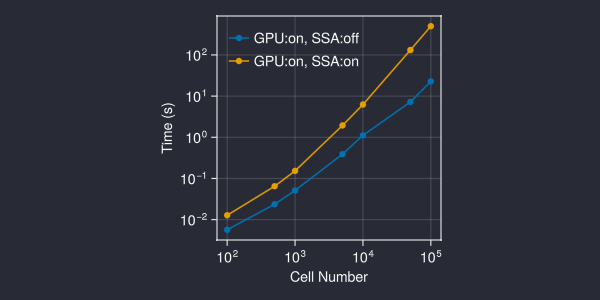

In [ ]:
fig = Figure(size=(600,300))
ax = Axis(
    fig[1,1],xlabel="Cell Number",ylabel="Time (s)",
    xscale=log10, yscale=log10, aspect=1,
)
scatterlines!(ax,tbssa0.N, tbssa0.time, label="GPU:on, SSA:off")
scatterlines!(ax,tbssa1.N, tbssa1.time, label="GPU:on, SSA:on")
#ts = 10 .^LinRange(2,5,100)
#lines!(ax1,ts,1e-3*ts.^1.0,color=:white,linestyle=:dot,linewidth=2)
axislegend(ax,position = :lt)
fig

### for Dynamo

In [ ]:
import JSON
tbdyn = let
    benchdir = "../benchmark/dynamo/results"
    files = readdir(benchdir,join=true)
    df = map(files) do file
        rep = match(r"_R(?<rep>\d+)",file)[:rep]
        open(file, "r") do io
            #content = replace(readline(io),"'" => "\"")
            content = readline(io)
            merge(JSON.parse(content),Dict("rep" => rep))
        end
    end |> DataFrame
    display(df[1:5,:])
    gdf = groupby(df, [:M,:N])
    mkeys = [:time,:mse_div,:mse_curl,:mse_detJ] 
    df = combine(gdf, mkeys .=> mean, renamecols=false)
    sort(df,[:M,:N])
end

Row,rep,mse_curl,M,time,N,mse_detJ,mse_div
,SubStrin…,Float64,Int64,Float64,Int64,Float64,Float64
1,1,0.0113963,1000,61.4288,100000,0.0116255,0.0117523
2,2,0.0113963,1000,61.8781,100000,0.0116255,0.0117523
3,3,0.0113963,1000,61.6201,100000,0.0116255,0.0117523
4,1,0.00397163,1000,14.9146,10000,0.00399553,0.00406202
5,2,0.00397163,1000,15.1737,10000,0.00399553,0.00406202


Row,M,N,time,mse_div,mse_curl,mse_detJ
,Int64,Int64,Float64,Float64,Float64,Float64
1,100,100,0.133402,0.152358,0.0980195,0.141548
2,100,500,0.258819,1.31476,0.292941,0.788914
3,100,1000,0.342681,0.392949,0.14019,0.334068
4,100,5000,2.48398,0.749205,0.45165,0.652208
5,100,10000,3.41899,0.265638,0.116531,0.16026
6,100,50000,12.1849,0.394521,0.289772,0.314686
7,100,100000,20.0357,0.428786,0.240904,0.244458
8,500,100,0.141471,0.152358,0.0980195,0.141548
9,500,500,5.03461,0.320874,0.0530721,0.189086


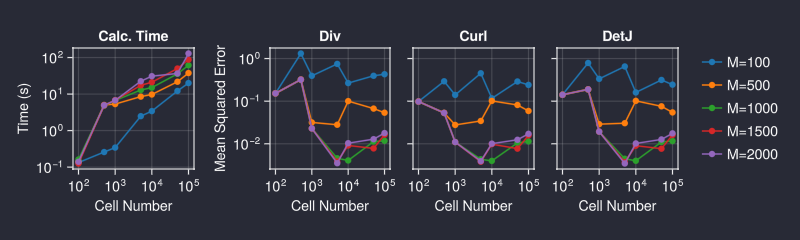

In [ ]:
fig = Figure(size=(800,240))
targets = [:mse_div, :mse_curl, :mse_detJ]
ax = Axis(
    fig[1,1],xlabel="Cell Number",ylabel="Time (s)",
    xscale=log10, yscale=log10, aspect=1,
    title="Calc. Time"
)
axs = [
    Axis(
        fig[1,i+1],xlabel="Cell Number",
        xscale=log10, yscale=log10, aspect=1,
        title = titlecase(string(x)[5:end],strict=false)
    ) for (i,x) in enumerate(targets)
]
axs[1].ylabel = "Mean Squared Error"

Ms = sort(unique(tbdyn.M))
pal = Dict(zip(Ms,resample_cmap(:tab10, 10)))
for M in Ms
    tbdyn_m = tbdyn[tbdyn.M .== M,:]
    scatterlines!(ax, color=pal[M],
        tbdyn_m.N, tbdyn_m.time, label="M=$M",
    )
    tb2k = tbdyn[tbdyn.M .== M,:]
    for (i,target) in enumerate(targets)
        scatterlines!(axs[i],
            tbdyn_m.N, tbdyn_m[!,target], color=pal[M],
        )
    end
end

# ddhcol = :orange
# scatterlines!(ax,tb.N,tb.time,label="ddHodge\n(GPU)",color=ddhcol)
# for (i,target) in enumerate(targets)
#     scatterlines!(axs[i],tb.N,tb[!,target],color=ddhcol)
# end

[axs[i].yticklabelsvisible = false for i in 2:length(targets)]
#axislegend(ax1,position=:rb,labelsize=10,nbanks=2)
#axislegend(ax2,position=:rt)
Legend(fig[1,5],ax)
linkyaxes!(axs...)
#colsize!(fig.layout, 2, Fixed(200))
fig

### Comparison to the best performance of Dynamo

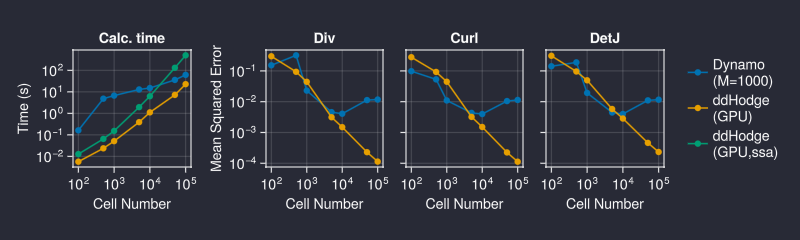

In [ ]:
M = 1000
fig = Figure(size=(800,240))
ax = Axis(
    fig[1,1],
    xlabel="Cell Number",ylabel="Time (s)",
    xscale=log10, yscale=log10, aspect=1,
    title="Calc. time"
)
axs = [
    Axis(
        fig[1,i+1], xlabel="Cell Number",
        xscale=log10, yscale=log10, aspect=1,
        title = titlecase(string(x)[5:end],strict=false)
    ) for (i,x) in enumerate(targets)
]
axs[1].ylabel = "Mean Squared Error"
tb2k = tbdyn[tbdyn.M .== M,:]
scatterlines!(ax,tb2k.N,tb2k.time,label="Dynamo\n(M=$M)")
scatterlines!(ax,tbssa0.N,tbssa0.time,label="ddHodge\n(GPU)")
scatterlines!(ax,tbssa1.N,tbssa1.time,label="ddHodge\n(GPU,ssa)")
for (i,target) in enumerate(targets)
    scatterlines!(axs[i],tb2k.N, tb2k[!,target],)
    scatterlines!(axs[i],tbssa0.N,tbssa0[!,target])
    #scatterlines!(axs[i],tbssa1.N,tbssa1[!,target])
end
#axislegend(ax,position=:rb)
Legend(fig[1,5],ax)
[axs[i].yticklabelsvisible = false for i in 2:length(targets)]
linkyaxes!(axs...)
fig